In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# 실습 준비 — 02주차 1차원 데이터 정리 — 지표 계산·시각화
# 이 셀을 먼저 한 번 실행하세요. 데이터가 없으면 아래 셀들이 전부 실패합니다.
import os, pathlib, urllib.request

BASE = "https://raw.githubusercontent.com/aprilslab/statistics-lab/main/data/"
FILES = ["ch2_scores_em.csv"]

pathlib.Path("data").mkdir(exist_ok=True)
for name in FILES:
    for dest in (pathlib.Path(name), pathlib.Path("data") / name):
        if not dest.exists():
            urllib.request.urlretrieve(BASE + name, dest)

# '../data/x.csv' 로 읽는 노트북 대응 — 상위 폴더에도 같은 data/ 를 걸어둔다.
# 절대경로(/data)로 박으면 cwd 가 /content 가 아닐 때 깨지므로 상대경로로 건다.
try:
    parent = pathlib.Path("..") / "data"
    if not parent.exists():
        os.symlink(pathlib.Path("data").resolve(), parent)
except OSError:
    pass

print("준비 완료:", ", ".join(FILES) if FILES else "(내려받을 데이터 없음)")


준비 완료: ch2_scores_em.csv


# 1차원 데이터의 정리 (부제: 데이터의 특징 파악)

In [ ]:
# 우리는 colab에 파일을 올려놓고 데이터를 읽어 올 것이기 때문에 google drive를 먼저 연결해줍니다.
# 좌측의 폴더 버튼을 누르세요.
# 상단의 구글 마크가 있는 폴더 버튼을 눌러서 마운트 해주세요.
# 마운트 버튼을 누르면 코랩을 연결하는 코드 셀이 생성됩니다.


In [75]:
import os
work_dir = '/content/data'
os.chdir(work_dir)

In [9]:
# 현재 폴더에 있는 파일 목록을 출력해봅니다.
!ls

ch2_scores_em.csv


## 2.1 데이터 중심의 지표

In [10]:
# 데이터의 특징을 파악하는 방법 중 하나는 데이터를 요약하는 것입니다.
# 대푯값이라고도 합니다.
# 대푯값을 계산하기 위한 준비물로 pandas와 numpy를 준비해줍니다.

import numpy as np
import pandas as pd

# Jupyter Notebook의 출력을 소수점 이하 3자리로 제한
%precision 3
# Dataframe의 출력을 소수점 이하 3자리로 제한
pd.set_option('display.precision', 3)
# Numpy의 출력을 소수점 이하 3자리로 제한
np.set_printoptions(precision=3)

In [11]:
# 'ch2_scores_em.csv' 파일을 읽어 DataFrame으로 만들어 줍니다.
# 이 데이터는 2장과 3장에서 사용할, 학생 50명의 수학과 영어 시험 점수가 들어있습니다.
# index_col로 'student number'을 지정해줍니다.
df = pd.read_csv('ch2_scores_em.csv', index_col='student number')
df.head()

,english,mathematics
student number,,
1,42,65
2,69,80
3,56,63
4,41,63
5,57,76


In [13]:
# 영어점수를 numpy로 계산하기 위해 array 데이터 구조로 된 scores 라는 이름으로 저장합니다.
# 학생번호 10번까지만 잘라서 사용합니다.
scores = np.array(df['english'])[:10]
scores

array([42, 69, 56, 41, 57, 48, 65, 49, 65, 58])

, 'C

In [15]:
# scores_df라는 이름으로 pandas의 DataFrame을 작성합니다.
# index로는 'student'라는 이름을 만들어 줍니다.
# ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

scores_df = pd.DataFrame({'scroe':scores}, index = pd.Index(['A', 'B','C', 'D', 'E','F', 'G', 'H', 'I', 'J'], name = 'students'))
scores_df

,scroe
students,
A,42
B,69
C,56
D,41
E,57
F,48
G,65
H,49
I,65


### 평균값 (mean)

In [16]:
# 평균값 수식
# 평균은 다음과 같이 표기를 주로 사용하며 '엑스 바'라고 읽습니다.
from IPython.display import display, Math
display(Math(r"\bar{x} = \frac{1}{n}{\sum_{i=1}^{n} x_i}"))

<IPython.core.display.Math object>

In [17]:
# 평균값은 가장 잘 알려진 대푯값입니다.
# 평균값: (모든 데이터의 합) / (데이터의 개수)
# 합계를 구하는 함수: sum(np.array)
# 개수를 구하는 함수: len(np.array)

sum(scores) / len(scores)

np.float64(55.0)

In [18]:
# numpy 함수를 사용하여 구해봅니다.
np.mean(scores)

np.float64(55.0)

In [19]:
# pandas 에서도 함수를 제공합니다.
scores_df.mean()

,0
scroe,55.0


In [20]:
# 이 교재에서는 numpy의 함수를 사용하는 것으로 통입합니다.
# numpy와 pandas의 함수명은 통계 용어의 영단어를 그대로 사용하거나 약칭한 것이 대부분이기 때문에 영어표현은 외워 두시기 바랍니다.
# 변수에 이름을 붙이거나 함수를 찾을 때 편리합니다.

### 중앙값 (median)

In [21]:
# 중앙값은 데이터를 크기순서대로 나열할 때 정확하게 중앙에 위치한 값입니다.
# 중앙값은 평균값에 비해 이강삾에 강하다는 특징이 있습니다.
# 데이터에 큰 이상값이 있는 경우 대푯값으로 평균값보다는 중앙값이 적절합니다.
# numpy의 sort 함수로 scores를 정렬합니다.
sorted_scores = np.sort(scores)
# 중앙값은 크기 순서대로 데이텅를 나열할 때 정확히 중앙에 위치한 값, 이상값에 영향 덜 받
sorted_scores

array([41, 42, 48, 49, 56, 57, 58, 65, 65, 69])

In [22]:
# 중앙값은 데이터 개수가 짝수일 때는 중앙에 위치하는 값이 2개입니다.
# 이 경우 중앙값은 두 값의 평균값으로 정의됩니다.
# 홀수일 경으 (n+1)/2가 중앙
n = len(sorted_scores)
if n % 2 == 0:
    m0 = sorted_scores[n//2 - 1]
    m1 = sorted_scores[n//2]
    median = (m0 + m1) / 2
else:
    median = sorted_scores[(n+1)//2 - 1]
median

np.float64(56.5)

In [23]:
# numpy 의 median 함수를 사용하여 구해봅니다.
np.median(scores)

np.float64(56.5)

In [24]:
# pandas 에서도 함수를 제공합니다.
scores_df.median()

,0
scroe,56.5


### 절사 평균
양쪽 끝을 조금씩 잘라내고 남은 값들의 평균
- 이상값 영향 별로 받지 않음
- 정보의 손실이 적음
- 체조, 피겨스케이팅 등

### 최빈값 (mode)

In [25]:
# 최빈값은 데이터에서 가장 많이 나타나는 값입니다.
# 최빈값은 기본적으로 질적 데이터의 대푯값을 구할 때 사용하는 지표입니다.
# 양적 데이터에서는 최빈값을 구하려고 해도 완전히 동일한 값이 나오는 경우가 거의 없기 때문입니다.
pd.Series([1, 1, 1, 2, 2, 3]).mode()

,0
0,1


In [26]:
# pandas의 DataFrame이나 Series이 mode 함수로 구할 수 있습니다.
pd.Series([1, 2, 3, 4, 5]).mode()

,0
0,1
1,2
2,3
3,4
4,5


## 2.2 데이터의 산포도 지표

In [27]:
# 데이터를 특징을 파악하기 위해 데이터가 떨어져 있는 정도를 파악하기 위한 지표를 계산해봅시다.

### 분산과 표준편차

In [28]:
# 편차는 각 데이터가 평균으로부터 어느정도 떨어져 있는가를 나타내는 지표입니다.

#### 편차 (deviation)
/dɪˈveɪʃən/ <br>
디비에이션 <br>
디베이션


In [29]:
# numpy의 brodcast 기능을 이용해서 한번에 여러 편차를 구할 수 있습니다.
# 편차: (각 학생의 점수) - (평균)
mean = np.mean(scores)
deviation = scores - mean
deviation

array([-13.,  14.,   1., -14.,   2.,  -7.,  10.,  -6.,  10.,   3.])

In [30]:
# 여기 평균값이 55로 맞춰진 다른 시험점수가 있습니다.
another_scores = [50, 60, 58, 54, 51, 56, 57, 53, 52, 59]
another_mean = np.mean(another_scores)
another_deviation = another_scores - another_mean
another_deviation

array([-5.,  5.,  3., -1., -4.,  1.,  2., -2., -3.,  4.])

In [32]:
# numpy의 mean함수로 편차의 평균을 내봅시다.
np.mean(deviation)

np.float64(0.0)

In [34]:
# 다른 시험점수의 편차의 평균을 내봅시다.
mean = np.mean(another_scores)

In [35]:
# 편차의 평균은 늘 {}이 나온다. 정답: 0

In [36]:
# scores_df에 있는 점수를 DataFrame을 사용해서 예쁘게 출력해볼까요?
summary_df = scores_df.copy()
summary_df['deviation'] = deviation
summary_df

,scroe,deviation
students,,
A,42,-13.0
B,69,14.0
C,56,1.0
D,41,-14.0
E,57,2.0
F,48,-7.0
G,65,10.0
H,49,-6.0
I,65,10.0


In [37]:
# pandas의 mean 함수를 통해 각 열의 평균을 확인해 봅시다.
summary_df.mean()

,0
scroe,55.0
deviation,0.0


#### 분산 (variance)
/ˈværɪəns/ <br>
베어리언스

In [38]:
display(Math(r"{S}^2 = \frac{1}{n}{\sum_{i=1}^{n} ({x_i - \bar{x}})^2}"))

<IPython.core.display.Math object>

In [39]:
# 산포도의 대푯값을 구할 때, 편차는 편차의 평균이 항상 0이기 때문에 사용할 수 없습니다.
# 흩어진 정도를 표기한다는 관점에서 -14점이나 +14점이나 동일한 산포도를 가지고 있습니다.
# 이처럼 산포도의 관점에서 -14점이나 +14점을 동일하게 취급하며 편차의 제곱을 이용합니다. 그리고 거기에 평균을 구한것이 '분산'입니다.
# 분산: 'deviation 제곱'의 평균

# python에서 제곱은 n ** 2로 구합니다.
# 분산을 구해봅시다.
np.mean(deviation ** 2)

np.float64(86.0)

In [40]:
# numpy의 var 함수로 구할 수 있습니다.
np.var(scores)

np.float64(86.0)

In [41]:
# pandas에서도 함수를 제공합니다.
scores_df.var()

,0
scroe,95.556


In [42]:
# 편차의 제곱(square)을 summary_df에 넣고 예쁘게 출력해봅시다.
summary_df['square of deviation'] = np.square(deviation)
summary_df

,scroe,deviation,square of deviation
students,,,
A,42,-13.0,169.0
B,69,14.0,196.0
C,56,1.0,1.0
D,41,-14.0,196.0
E,57,2.0,4.0
F,48,-7.0,49.0
G,65,10.0,100.0
H,49,-6.0,36.0
I,65,10.0,100.0


In [43]:
# pandas의 평균함수를 호출해봅니다.
summary_df.mean()

,0
scroe,55.0
deviation,0.0
square of deviation,86.0


#### 표준편차 (standard deviation)

In [44]:
# 평균은 원래 데이터와 같은 단위를 쓰기 때문에 원래의 데이터가 쓰는 단위를 붙여서 표현 할 수 있습니다. 예: '평균 점수'
# 분산은 원래 데이터와 다른 단위를 쓰기 때문에, 같은 단위로 만들기 위해 제곱근을 취해 단위를 같게 만들어줍니다.
# 분산에 제곱근을 취한 값을 표준편차라고 합니다.
display(Math(r"{S}^2 = \sqrt{{S}^2} = \sqrt{\frac{1}{n}{\sum_{i=1}^{n} ({x_i - \bar{x}})^2}}"))

<IPython.core.display.Math object>

In [45]:
# 표준편차는 numpy의 var 함수와 sqrt 함수를 사용하여 계산할 수 있습니다.
np.sqrt(np.var(scores, ddof=0))

np.float64(9.273618495495704)

In [46]:
# numpy의 std 함수로 바로 구할 수도 있습니다.
np.std(scores, ddof=0)

np.float64(9.273618495495704)

### 범위와 4분위수 범위

#### 범위 (range)

In [47]:
# 범위는 데이터 전체를 보고 산포도를 표현하는 것이 아니라, 최댓값과 최솟값만으로 산포도를 표현하는 방법입니다.
# 값을 2개만 보기 때문에 개략적인 지표이고, 이상값에 약합니다.
display(Math(r"{Rg} = {x_{\max} - x_{\min}}"))

<IPython.core.display.Math object>

In [48]:
# numpy의 max 함수와 min 함수로 계산할 수 있습니다.
np.max(scores) - np.min(scores)

np.int64(28)

#### 4분위수 범위 (interquartil range)
/ˌɪntəˈkwɔːtaɪl ˈreɪndʒ/ <br>
인터콰타일 레인지

In [49]:
# 범위는 이상값에 약하기 때문에 몹시 큰 이상값이 하나라도 있으면 범위가 크게 변화합니다.
# 그래서 최댓값, 최솟값이 아니라, 이상값이 없을 법한 상위값에서 하위값을 빼는 방법으로 산포도를 표현하는 방법을 생각해 볼 수 있습니다.
# 사분위 범위에서는 데이터의 하위 25%(1분사분위수: Q1), 50%(2사분위수: Q2), 75%(3사분위수: Q3)에 위치하는 값에 주목합니다.
# Q3 - Q1을 사분위 범위 'IQR'로 정의합니다.
display(Math(r"{IQR} = {Q3} - {Q1}"))

<IPython.core.display.Math object>

In [50]:
# numpy의 percentile 함수로 계산할 수 있습니다.
scores_Q1 = np.percentile(scores, 25)
scores_Q3 = np.percentile(scores, 75)
scores_IQR = scores_Q3 - scores_Q1
scores_IQR

np.float64(15.0)

### 데이터의 지표 정리

In [51]:
# DataFrame에는 지금까지 다른 다양한 지표를 한번에 구할 수 있는 describe 함수를 제공합니다.
# 데이터가 주어지면 describe로 개요를 파악해보는 것도 좋습니다.
pd.Series(scores).describe()

,0
count,10.000
mean,55.000
std,9.775
min,41.000
25%,48.250
50%,56.500
75%,63.250
max,69.000


## 2.3 데이터의 정규화 (normalization)
/nɔːrməlaɪˈzeɪʃən/ <br>
노말라이제이션

In [52]:
# 시험점수가 동일한 60점이라도, 어려운 시험과 쉬운 시험에서의 상대적 결과는 다릅니다.
# 점수라는 지표는 그 시험의 평균과 분산에 따라 평가가 달라집니다.
# 평균이나 분산에 의존하지 않고도 데이터의 상대적인 위치 관계를 알 수 있는 지표로 변환하는 것을 '정규화'라고 합니다.
# 정규화를 통해 다양한 데이터를 동일한 기준으로 다룰 수 있습니다.

### 표준화 (standardization)
/ˌstændərdɪˈzeɪʃən/ <br>
스탠더다이제이션

In [53]:
# 데이터에서 평균을 빼고 표준 편차로 나누는 작업을 '표준화'랍고합니다.
# 표준화된 데이터를 '표준화 변량' 또는 'Z 점수'라고 합니다.
# 각 데이터 x[i]를 표준화한 z[i]를 수식으로 나타내면 다음과 같습니다.
display(Math(r"{z_i} = \frac{{x_i - \bar{x}}}{{S}}"))

<IPython.core.display.Math object>

In [54]:
# numpy의 mean함수, std함수로 z 점수를 계산할 수 있습니다.
z = (scores - np.mean(scores)) / np.std(scores)
z

array([-1.402,  1.51 ,  0.108, -1.51 ,  0.216, -0.755,  1.078, -0.647,
        1.078,  0.323])

In [55]:
# 표준화된 데이터는 평균이 0, 표준편차가 1입니다.
# z 의 평균과 표준편차를 출력해봅시다.
np.mean(z), np.std(z, ddof=0)

(np.float64(-1.6653345369377347e-17), np.float64(0.9999999999999999))

### 편차값

In [56]:
# 편차값은정규화한 값을 말합니다.
# 평균이 50, 표준편차가 10이 되도록 정규화한 편차값을 수직으로 나타내면 다음과 같습니다.
display(Math(r"{z_i} = { 50 + 10 \times \frac{{x_i} - \bar{x}}{S} }"))

<IPython.core.display.Math object>

In [57]:
# numpy의 mean 함수, std 함수를 이용해서 평균이 50, 표준편차가 10인 편차값을 계산할 수 있습니다.
z = 50 + 10 * (scores - np.mean(scores)) / np.std(scores)
z

array([35.982, 65.097, 51.078, 34.903, 52.157, 42.452, 60.783, 43.53 ,
       60.783, 53.235])

In [58]:
# DataFrame으로 정리하여 점수와 편차값의 관계를 살펴봅시다.
scores_df['deviation value'] = z
scores_df

,scroe,deviation value
students,,
A,42,35.982
B,69,65.097
C,56,51.078
D,41,34.903
E,57,52.157
F,48,42.452
G,65,60.783
H,49,43.530
I,65,60.783


## 2.4 데이터의 시각화

In [59]:
# 지금까지 데이터 요약을 통해 데이터의 특징을 파악해보았습니다.
# 이제는 표나 그림을 통해 시작화를 통해 데이터의 특징을 파악해봅시다.
# 50명의 영어 점수에 대한 array를 작성하고

# pandas Series의 describe 함수로 주요 지표들을 확인해봅시다.

english_scores = np.array(df['english'])[:10]
pd.Series(english_scores).describe()


,0
count,10.000
mean,55.000
std,9.775
min,41.000
25%,48.250
50%,56.500
75%,63.250
max,69.000


### 도수분포표 (frequency distribution table)
프리퀀시 디스트리뷰션 테이블

In [60]:
# 데이터의 분포상태를 알고 싶을 때, 데이터를 몇개의 구간으로 나누고, 각 구간에 몇 개의 데이터가 들어가는 지 세는 방법이 있습니다.
# 이처럼 분할된 구간과 데이터의 개수를 표로 정리한 것이 '도수분포표'입니다.
# 예) 시험점수를 10점 간격으로 나누어 도수분포표를 작성한다 했을 때,
#    - 계급(class): 각 구간 (0~10,10~20, ... , 90~100)
#    - 도수(frequency): 각 계급에 속한 학생 수
#    - 계급폭: 각 구만의 폭 (10)
#    - 계급수: 총 계급의 수 (100점을 폭 10 단위로 나누면 계급수는 100/10 = 10)
#    - 계급값: 각 계급을 대표하는 값
#    - 상대도수: 전체 데이터에서 해당 계급의 데이터가 어느정도의 비율을 차지하고 있는지
#    - 누적상대도수: 해당 계급까지의 상대도수의 합

# numpy의 histogram 함수로 도수를 계산할 수 있습니다.
freq, _ = np.histogram(scores, bins=10, range=(0,100))
freq

array([0, 0, 0, 0, 4, 3, 3, 0, 0, 0])

In [61]:
# 0~10, 10~20, ... 이라는 문자열의 리스트를 작성
freq_class = [f'{i}~{i+10}' for i in range(0, 100, 10)]
# 도수분포표 작성: 계산한 도수를 frequency열로, freq_class를 인덱스로 하여 DataFrame을 작성합니다.
freq_dist_df = pd.DataFrame({'frequency':freq}, index=pd.Index(freq_class, name='class'))
freq_dist_df

,frequency
class,
0~10,0
10~20,0
20~30,0
30~40,0
40~50,4
50~60,3
60~70,3
70~80,0
80~90,0


In [62]:
# 계급값을 계산해봅니다. 계급값은 계급의 중앙값이 이용됩니다.
class_value = [(i+(i+10))//2 for i in range(0, 100, 10)]
class_value

[5, 15, 25, 35, 45, 55, 65, 75, 85, 95]

In [64]:
# 상대도수는 도수에서 도수의 합을 나눠서 계산할 수 있습니다.
rel_freq = freq / freq.sum()
rel_freq

array([0. , 0. , 0. , 0. , 0.4, 0.3, 0.3, 0. , 0. , 0. ])

In [65]:
# 누적상대도수는 numpy의 cumsum 함수로 계산할 수 있습니다.
cum_rel_freq = np.cumsum(rel_freq)
cum_rel_freq

array([0. , 0. , 0. , 0. , 0.4, 0.7, 1. , 1. , 1. , 1. ])

In [66]:
# 계급값, 상대도수, 누적상대도수도 도수분포표에 추가합니다.
freq_dist_df['class value'] = class_value
freq_dist_df['relative frequency'] = rel_freq
freq_dist_df['cumulative relative frequency'] = cum_rel_freq
freq_dist_df = freq_dist_df[['class value', 'frequency',
                             'relative frequency', 'cumulative relative frequency']]

freq_dist_df

,class value,frequency,relative frequency,cumulative relative frequency
class,,,,
0~10,5,0,0.0,0.0
10~20,15,0,0.0,0.0
20~30,25,0,0.0,0.0
30~40,35,0,0.0,0.0
40~50,45,4,0.4,0.4
50~60,55,3,0.3,0.7
60~70,65,3,0.3,1.0
70~80,75,0,0.0,1.0
80~90,85,0,0.0,1.0


#### 최빈값 재검토

In [67]:
# 도수분포표가 완성되었습니다.
# 이를 이용해 양적 데이터에서도 최빈값을 구할 수 있습니다.
# 도수분포표를 사용한 최빈값은 최대가 되는 계급의 계급값으로 정의됩니다.

# freq_dist_df에서 도수(frequency)가 가장 큰행의 인덱스를 찾는 Series의 idxmax 함수로 최빈값 행을 찾을 수 있습니다.
# 해당행의 계급값이 최빈값입니다.


### 히스토그램 (histogram)

In [68]:
# 히스토그램은 도수분포표를 막대그래프로 나타낸 것입니다.
# 여기서는 Matplotlib라는 라이브러리로 그래프를 그려봅니다.

# Matplotlib의 pyplot 모듈을 plt라는 이름으로 임포트
import matplotlib.pyplot as plt

# 그래프가 notebook 위에 표시
%matplotlib inline

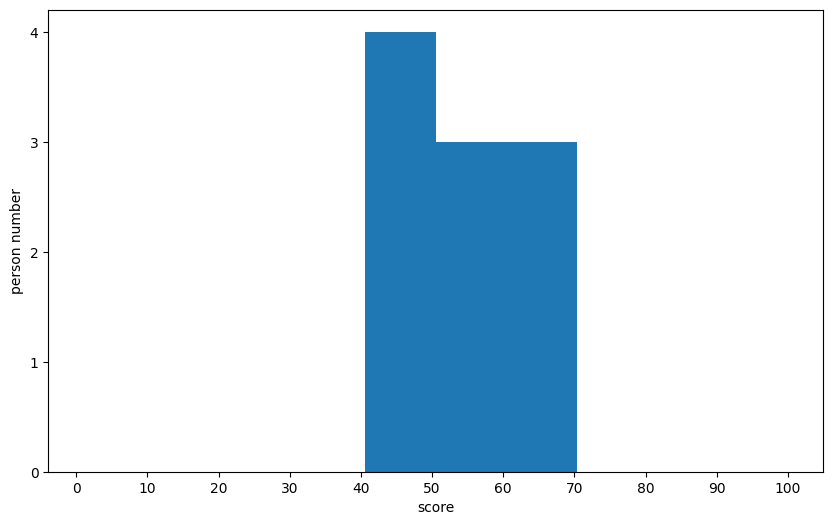

In [69]:
# 캔버스를 생성
# figsize로 가로・세로 크기를 지정
fig = plt.figure(figsize=(10, 6))
# 켄버스 위에 그래프를 그리기 위한 영역을 지정
# 인수는 영역을 1×1개 지정、하나의 영역에 그린다는 것을 의미
ax = fig.add_subplot(111)

# 계급수를 10으로 하여 히스토그램을 그림
freq, _, _ = ax.hist(english_scores, bins=10, range=(1,100))
# X축에 레이블 부여
ax.set_xlabel('score')
# Y축에 레이블 부여
ax.set_ylabel('person number')
# X축을 0, 10, 20, ..., 100 눈금으로 구분
ax.set_xticks(np.linspace(0, 100, 10+1))
# Y축을 0, 1, 2, ...의 눈금으로 구분
ax.set_yticks(np.arange(0, freq.max()+1))
# 그래프 표시
plt.show()

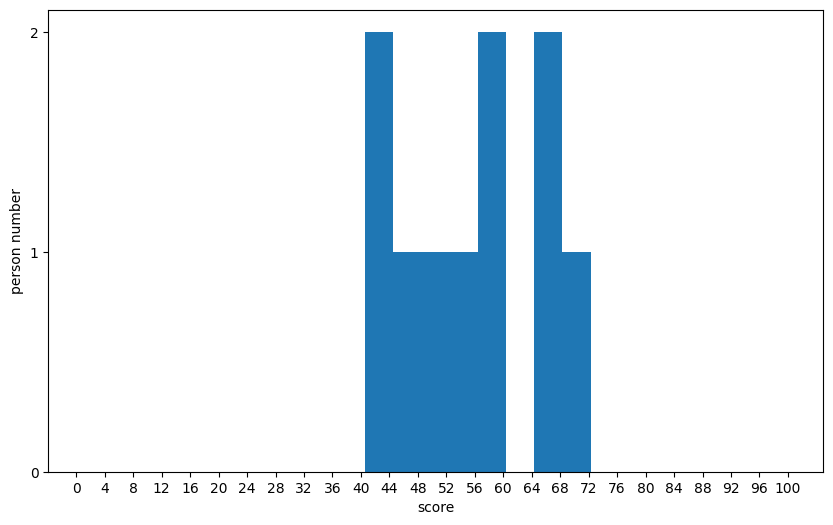

In [70]:
# 계급수를 10에서 25로 늘려 더 세부적인 데이터 분포를 확인해봅시다.
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

freq, _ , _ = ax.hist(english_scores, bins=25, range=(1,100))
ax.set_xlabel('score')
ax.set_ylabel('person number')
ax.set_xticks(np.linspace(0, 100, 25+1))
ax.set_yticks(np.arange(0, freq.max()+1))
plt.show()

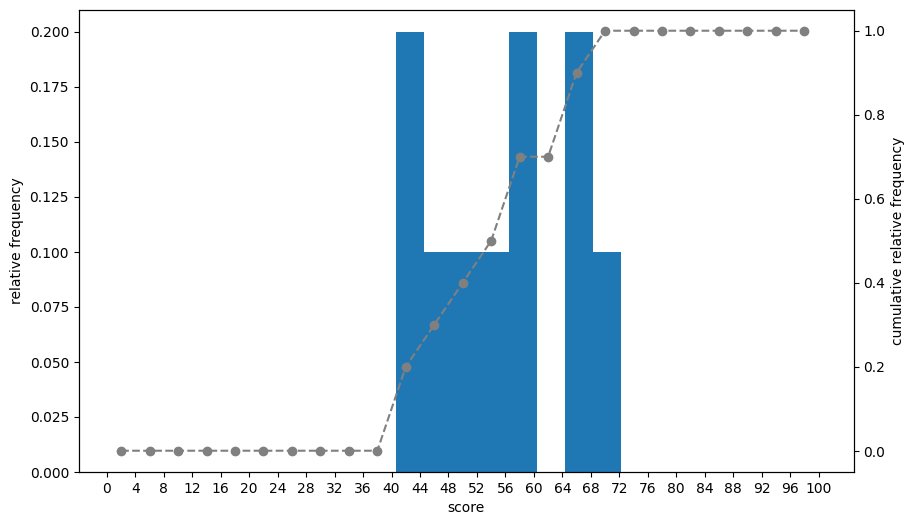

In [74]:
# 상대도수의 히스토그램을 누적상대도수의 꺽은선 그래프와 함께 그립니다.

fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(111)
# Y축의 스케일이 다른 그래프를 ax1과 동일한 영역에 생성
ax2 = ax1.twinx()

# 상대도수의 히스토그램으로 하기 위해서는, 도수를 데이터의 수로 나눌 필요가 있음
# 이것은 hist의 인수 weight를 지정하면 실현 가능
weights = np.ones_like(english_scores) / len(english_scores)
rel_freq, _, _ = ax1.hist(english_scores, bins=25, range=(1,100), weights=weights)

cum_rel_freq = np.cumsum(rel_freq)
# 계급값을 계산
class_value = [(i+(i+4))//2 for i in range(0,100,4)]
# 꺾은선 그래프를 그림
# 인수 ls를 '--'로 하면 점선이 그려짐
# 인수 marker를 'o'으로 하면 데이터 점을 그람
# 인수 color를 'gray'로 하면 회색으로 지정
ax2.plot(class_value, cum_rel_freq, ls='--', marker='o', color='gray')
# 꺾은선 그래프의 눈금선을 제거
ax2.grid(visible=False)

ax1.set_xlabel('score')
ax1.set_ylabel('relative frequency')
ax2.set_ylabel('cumulative relative frequency')
ax1.set_xticks(np.linspace(0, 100, 25+1))

plt.show()

### 상자 그림 (box plot)


/tmp/ipykernel_1531/4154966134.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(english_scores, labels=['english'])


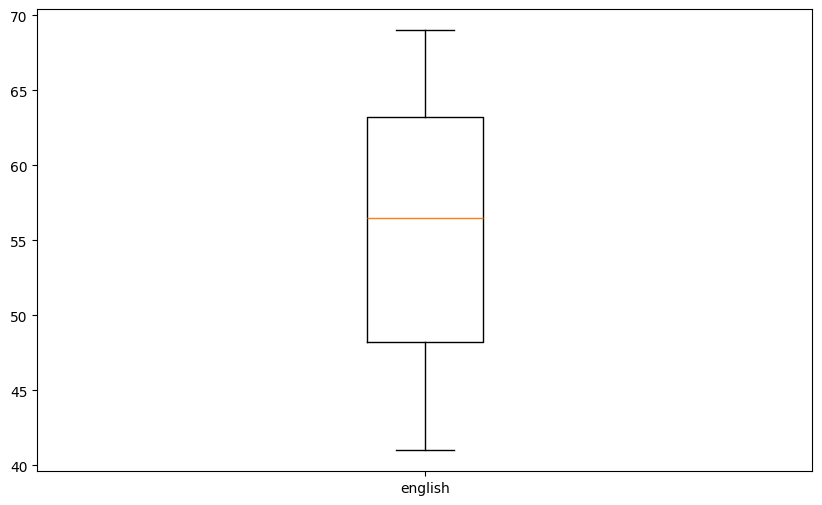

In [72]:
# 상자그림은 데이터의 산포도를 표현하는 그림입니다.
# 상자그림을 통해 데이터의 분포와 이상값을 시각적으로 파악할 수 있습니다.

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.boxplot(english_scores, labels=['english'])

plt.show()

In [73]:
name = "아무개"
num = "20250101"
print(f"이름: {name}, 학번: {num}")

이름: 아무개, 학번: 20250101
